(Tutorial_Get_vectors)=
# Get vectors

*Computing directed vectors between atoms or centers of selections.*

Vectors retain the direction and sense lost in a scalar distance. The first endpoint is the origin and the second is the destination; returned vectors carry length units. The experimental tool accepts coordinate-bearing forms, including structures-only H5MSM files.

:::{admonition} API documentation
:class: dropdown
{func}`molsysmt.structure.get_vectors`
:::

:::{versionadded} 1.0.0
:::


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import molsysmt as msm
from molsysmt import pyunitwizard as puw
from molsysmt.native import Structures

molsys = msm.convert(msm.systems['alanine dipeptide']['alanine_dipeptide.h5msm'],
                     to_form='molsysmt.MolSys')

:::{note} Demo Systems Catalog
:class: dropdown
This tutorial uses a bundled peptide. See {ref}`user-foundations-entrance-demo-systems` for the demonstration catalog.
:::

## Computing ordered atom vectors

Explicit pairs preserve their order and repetitions. A vector between two distinct atoms describes their relative position; it does not imply movement.

In [2]:
pairs = [[0, 1], [1, 0], [0, 1]]
vectors = msm.structure.get_vectors(molsys, selection=pairs, pairs=True, pbc=False)
assert vectors.shape == (1, 3, 3)
np.testing.assert_allclose(puw.get_value(vectors)[0, 0], -puw.get_value(vectors)[0, 1])
print(vectors.shape)

(1, 3, 3)


## Comparing all endpoint combinations

Without `pairs=True`, the result has axes `(structure_pair, first_endpoint, second_endpoint, xyz)`. Its norm matches the corresponding scalar distance. Cartesian products can be large; explicit pairs avoid allocating unwanted combinations.

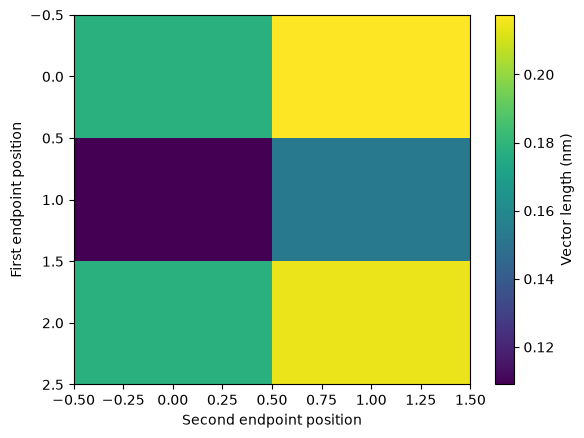

In [3]:
matrix = msm.structure.get_vectors(molsys, selection=[0, 1, 2], selection_2=[3, 4], pbc=False)
distances = msm.structure.get_distances(molsys, selection=[0, 1, 2], selection_2=[3, 4], pbc=False)
lengths = np.linalg.norm(puw.get_value(matrix, to_unit='nm'), axis=-1)
np.testing.assert_allclose(lengths, puw.get_value(distances, to_unit='nm'))
plt.imshow(lengths[0], aspect='auto')
plt.xlabel('Second endpoint position')
plt.ylabel('First endpoint position')
plt.colorbar(label='Vector length (nm)')
plt.show()

## Connecting centers of atom selections

Flat selections become one center with `center_of_atoms=True`. Nested selections define one center each; their order and overlapping memberships are retained. Unweighted centers are geometric centers. Use `weights='masses'` for a center of mass or supply nonnegative weights aligned with each membership.

This example connects atom collections from the bundled peptide. These atom collections are geometric memberships, not new chemical groups.

In [4]:
center_vectors = msm.structure.get_vectors(
    molsys, selection=[[0, 1, 2], [2, 3]], selection_2=[[4, 5], [5, 6, 7]],
    weights=[[1, 2, 1], [1, 1]], pairs=True, pbc=False)
center_of_mass_vector = msm.structure.get_vectors(
    molsys, selection=[0, 1, 2], center_of_atoms=True, weights='masses',
    selection_2=[4], pbc=False)
print(center_vectors.shape, center_of_mass_vector.shape)

(1, 2, 3) (1, 1, 1, 3)


## Comparing selected structures

The two structure-index lists are aligned by position and must have equal length. Nonconsecutive indices and repetitions remain meaningful. Compare `[0, 0, 0]` with `[1, 2, 3]` for displacement relative to a reference. The norm of an endpoint vector is not the total path length between those structures.

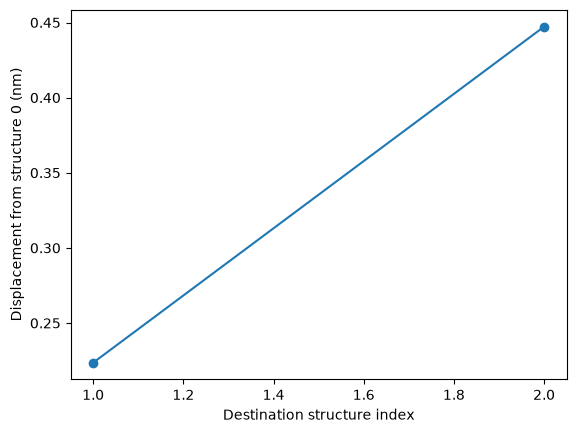

In [5]:
coordinates = puw.get_value(msm.get(molsys, coordinates=True), to_unit='nm')
translations = np.array([[0., 0., 0.], [.1, .2, 0.], [.2, .4, 0.]])
ensemble = Structures(coordinates=puw.quantity(coordinates + translations[:, None], 'nm'))
motion = msm.structure.get_vectors(
    ensemble, selection=[0], selection_2=[0], pairs=True,
    structure_indices=[0, 2, 0], structure_indices_2=[1, 0, 2], pbc=False)
np.testing.assert_allclose(puw.get_value(motion, to_unit='nm')[:, 0],
                           [[.1, .2, 0.], [-.2, -.4, 0.], [.2, .4, 0.]])
plt.plot([1, 2], np.linalg.norm(translations[1:], axis=1), 'o-')
plt.xlabel('Destination structure index')
plt.ylabel('Displacement from structure 0 (nm)')
plt.show()

## Comparing two sources and choosing units

Two systems must share a Cartesian reference. Their source atom indices need not refer to the same atoms. PyUnitWizard converts different input units and applies the active output length standard without changing the scientific result.

In [6]:
molsys_B = puw.quantity((coordinates + [.1, 0., 0.])*10, 'angstrom')
with puw.context(standard_units=['angstrom', 'ps']):
    shifted = msm.structure.get_vectors(molsys, selection=[0], molecular_system_2=molsys_B,
                                       selection_2=[0], pairs=True, pbc=False)
    assert puw.has_unit(shifted, 'angstrom')
    np.testing.assert_allclose(puw.get_value(shifted), [[[1., 0., 0.]]], atol=1e-12)

## Inspecting periodic images and normalized directions

Dictionary output is a flat typed result. It adds scalar distances, dimensionless normalized directions and integer images, plus packed atom memberships and both source structure-index lists. With row-vector boxes:

`vector = second_position + image_vector @ first_box - first_position`

The box of the first endpoint defines MIC, including comparisons with structures whose boxes differ. Missing first-source boxes give ordinary Cartesian vectors. A zero-length vector has zero distance and a NaN normalized direction. Images are zero without PBC.

:::{warning}
MIC does not reconstruct the route traveled across periodic boundaries. Half-cell ties follow the deterministic shared MIC rule; reversing endpoints need not choose the opposite tied vector. Periodic center memberships must already occupy one anchor-relative image. Reconstruct split components explicitly with the PBC tools before calculating centers.
:::


In [7]:
periodic = Structures(coordinates=puw.quantity([[[.1, 0., 0.], [1.9, 0., 0.]]], 'nm'),
                      box=puw.quantity([np.eye(3)*2], 'nm'))
result = msm.structure.get_vectors(periodic, selection=[[0, 1]], pairs=True,
                                   output_type='dictionary')
np.testing.assert_allclose(puw.get_value(result['vectors'], to_unit='nm'), [[[-.2, 0., 0.]]])
np.testing.assert_array_equal(result['image_vectors'], [[[-1, 0, 0]]])
print(result['directions'], result['structure_indices'])

[[[-1.  0.  0.]]] [0]


## Retaining array index outputs

For array output, `output_indices='atom'` prepends both source endpoint memberships and `output_structure_indices='structure'` prepends both source structure axes. `selection` requests local endpoint/structure positions. Dictionary output always retains the source mappings. Molecular group labels are not implemented as vector endpoint labels.

In [8]:
first_atoms, second_atoms, first_structures, second_structures, mapped = msm.structure.get_vectors(
    molsys, selection=[2, 0], selection_2=[3, 1], pairs=True, pbc=False,
    output_indices='atom', output_structure_indices='structure')
print(first_atoms, second_atoms, first_structures, second_structures, mapped.shape)

[2 0] [3 1] [0] [0] (1, 2, 3)


## Streaming coordinate blocks and handling empty results

`heavy_mode='force'` uses declared streaming routes for both endpoints. The complete vector result stays in RAM; streaming input does not remove that cost. Empty atom or structure axes have defined shapes. Invalid indices, incompatible paired counts, nonfinite coordinates and insufficient numerical memory budgets raise explicit errors. CPU execution follows `parallel` and `num_threads`; no GPU backend is offered by this tool.

In [9]:
streamed = msm.structure.get_vectors(ensemble, selection=[0], selection_2=[1],
                                     structure_indices=[2, 0, 2], pbc=False,
                                     heavy_mode='force', num_threads=2)
empty = msm.structure.get_vectors(ensemble, selection=[0], selection_2=[1],
                                  structure_indices=[], pbc=False)
print(streamed.shape, empty.shape)

(3, 1, 1, 3) (0, 1, 1, 3)


:::{seealso} Related Tools & References
:class: dropdown
- {func}`molsysmt.basic.convert` — Preparing a supported native representation.
- {func}`molsysmt.structure.get_distances` — Computing scalar endpoint distances.
- {func}`molsysmt.basic.get` — Retrieving structural attributes.
- {func}`molsysmt.pbc.wrap_to_mic` — Reconstructing supported covalent components.
- {ref}`user-foundations-performance-rust-core` — Understanding compiled geometry.
:::
